<a href="https://colab.research.google.com/github/d-toups/workout-data-analysis/blob/main/notebooks/workout_data_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Workout Data Analysis: Gender & Age Differences in Fitness Preferences & Calorie Burn

**Objective**:  
Explore how workout preferences and calorie expenditure differ by gender and age group using exploratory data analysis.

**Business Value**:  
These insights can help fitness apps, gyms, and wellness platforms create more targeted programs and recommendations.

## 1. Project Overview

## Project Goal
Analyze workout preferences and calorie expenditure patterns across different genders and age groups using exploratory data analysis.

**Business Context**:  
Understanding demographic differences in fitness behavior can help gyms, fitness apps, and health companies create more personalized programs and marketing strategies.

## Key Questions
- What workout types are most popular among different genders?
- How does calorie burn vary by age group and workout type?
- Are there noticeable differences in behavior between males and females?

## Tech Stack
- Python (pandas, seaborn, matplotlib)
- Jupyter Notebook

## 2. Imports and Setup

In [ ]:
# Import functions
import sys
import os
sys.path.append(os.path.abspath('..'))
from src.workout_data_analysis import (
    load_dataset,
    clean_dataset,
    plot_workout_by_age_group,
    plot_cpm,
    stats
)

# Import librabries
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import chi2_contingency, ttest_ind
import warnings; warnings.filterwarnings('ignore')

## 3. Data Loading and Cleaning

In [4]:
# Load and Clean the Dataset
df_raw = load_dataset("gym_members_exercise_tracking.csv")
df, df_male, df_female = clean_dataset(df_raw)

print(f"Dataset shape after cleaning: {df.shape}")
print(f"Male samples: {len(df_male)}, Female samples: {len(df_female)}")

Final dataset shape after cleaning: (973, 8)
Dataset shape after cleaning: (973, 8)
Male samples: 511, Female samples: 462


## Specific cleaning actions taken were:
- Add Calories Per Minute feature to aid further analysis
- Filter out ambiguous "Other" entries for gender
- Bin ages into age groups for cohort analysis
- Confirm data cleaning by checking unique values of gender and workout type
- Notably, the dataset contained no records for individuals over age 59. Thus, a Seniors cohort could not be analyzed.

## 4. Key Visualizations

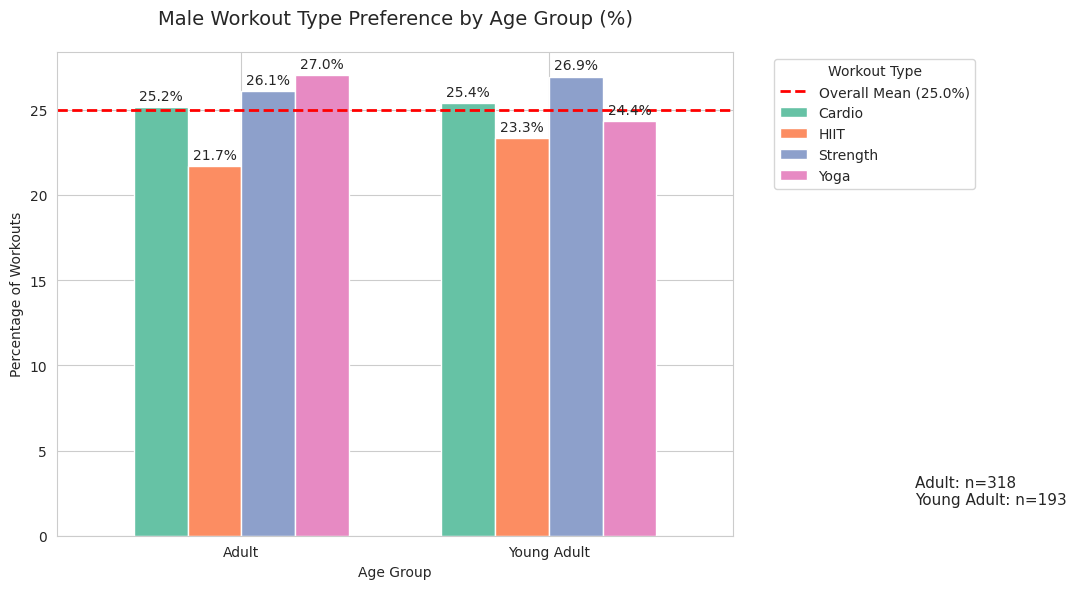

In [5]:
# 1. Plot Workout Preference by Age Group (Males)
plot_workout_by_age_group(df_male, 'Male')

**Male Workout Type Preferences**
- Adult males, surprisingly, show a preference for **Yoga**, though only slightly more than **Strength Training** and **Cardio**.
- Young Adults show a small preference for **Strength Training** as well as **Cardio**.
- The largest difference in preference between adult and young adult men is adults' 2.6% favorability of **Yoga**.
- Both groups favor **HIIT** least.

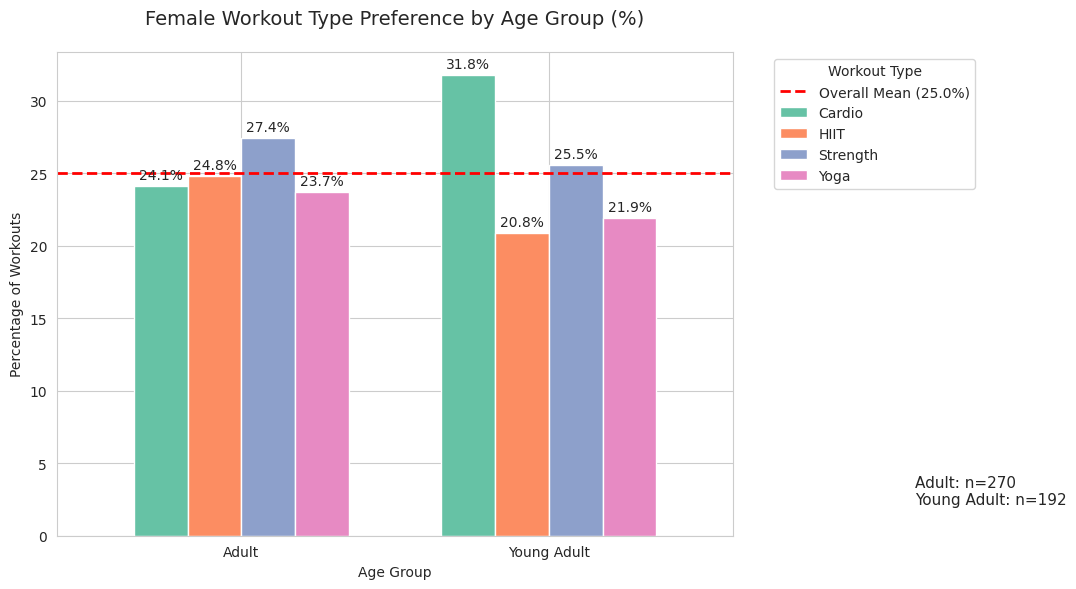

In [6]:
# 2. Plot Workout Preference by Age Group (Females)
plot_workout_by_age_group(df_female, 'Female')

**Female Workout Type Preferences**
- Adult females most strongly favor **Strength Training**.
- Young adult females prefer **Cardio** 6.3% above mean.
- Adult females least favor **Yoga**, while young adults prefer **HIIT** least.
- The largest difference between these groups is young adult females' 7.7% favorability of **Cardio** compared to adults.

**Overall Preference Insights**
- Both males and females consistently favor **Strength Training** and **Cardio** across both age groups, though adult men most prefer **Yoga**.
- The difference in workout preferences between genders is visible in both age groups, though the magnitude varies.

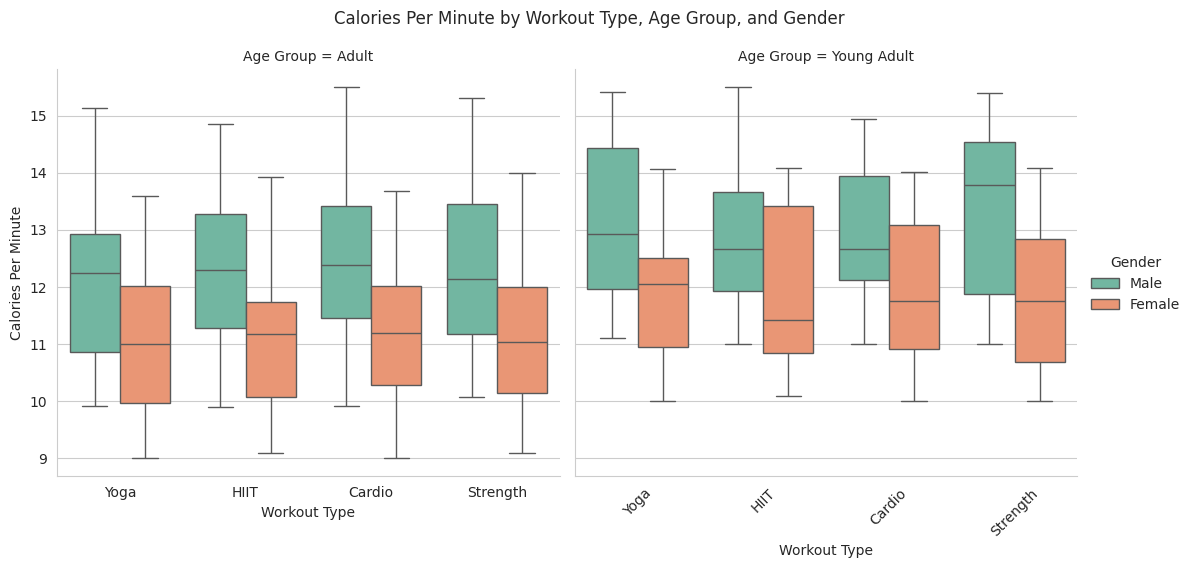

In [7]:
# 3. Plot Calories per Minute by Workout Type and Gender
plot_cpm(df)

**Intensity (Calories Per Minute)**
- **Young Adults** consistently perform higher intensity exercise in every category (as expected).
- **Young Adult males** tend to achieve the highest peak calorie burn rates, especially during Strength Training and Yoga.
- Females generally show more consistent (less variable) calorie burn across workout types compared to males, with exception of young adult female **HIIT** participants, who saw several high outliers.
- **Strength Training** exhibits the highest variability in intensity among males.

## 4. Statistical Analysis

- Stratified statistical tests (Chi-square and T-tests) showed **no statistically significant differences** between genders or age groups in this dataset (all p-values > 0.05).

## 5. Conclusions & Business Recommendations

**Key Findings**
- Clear visual patterns emerge: **Males** prefer higher-intensity workouts (Strength Training and HIIT), while **Females** favor Cardio and Yoga.
- **Young Adults** demonstrate higher training intensity compared to Adults in several workout types.
- **Strength Training** shows the highest variability in Calories Per Minute, especially among males, with several high outliers.

**Statistical Results**
- The **lack of statistically significant differences** between gender and age groups (all p > 0.05) suggests that while visual trends are present, they are not strong enough to reach statistical significance with this dataset.

**Business Implications**
- Fitness apps and gyms can still use these visual patterns to offer soft personalization (e.g., recommending more Strength/Crossfit options to young males).
- Caution is advised when implementing strong demographic-based assumptions due to the lack of statistical significance.

**Limitations**
- Seniors were excluded due to very small and non-representative sample size.
- The dataset is synthetic, which may limit generalizability.
- Moderate sample size likely contributed to non-significant statistical results.

**Future Work**
- Analyze a larger, real-world dataset
- Perform regression analysis to control for multiple variables